ARTI308 - Machine Learning

# Assignment 2: Data Quality Assessment & Preprocessing

In real-world machine learning projects, data is often:
- Incomplete (missing values)
- Noisy (outliers or random errors)
- Inconsistent (wrong formats, mixed units)

Before building any machine learning model, we must clean and prepare the data properly.

![step2.png](img/step2.png)

In this lab, we will apply practical preprocessing techniques step by step.

In [1664]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

## 1. Load Dataset

In [1665]:
pd.set_option("display.max_columns", None)
df = pd.read_csv("Titanic-Dataset.csv", sep=";")
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [1666]:
#me
import os
print(os.listdir())

['ARTI406 - Assignment 2.ipynb', 'Titanic-Dataset.csv']


## 2. Data Quality Assessment
### 2.1 Check Data Types
Data types must match the real meaning of each column.
For example:
- `Date` should be datetime
- `Revenue` should be numeric

In [1667]:
# Check data types
print(df.dtypes)


PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


After inspecting the Titanic dataset, no incorrect data types were found.

All numerical variables are already stored as integer or float data types, while categorical variables are stored as object data types.

Therefore, no data type conversion was required.

In [1668]:
# Check missing values
print("******************Check missing values*********************")
print(df.isnull().sum())
print("******************Check duplicates*********************")
# Check duplicates
print("Duplicates:", df.duplicated().sum())
#check shape
print("******************check shape*********************")
print(df.shape)
#check basic statistics
print("******************check basic statistics*********************")
print(df.describe())

******************Check missing values*********************
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
******************Check duplicates*********************
Duplicates: 0
******************check shape*********************
(891, 12)
******************check basic statistics*********************
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.5000

## Task 1: Data Quality Issues Summary

After inspecting the Titanic dataset, the following issues were identified:

1. Missing Values:
Age: 177 missing values (19.87%),  
Cabin: 687 missing values (77.1%)  too many missing, 
Embarked: 2 missing values (0.22%) 

2. Duplicates: No duplicate rows found (0 duplicates)

3. Dataset Shape: the dataset has 891 rows and 12 columns

4. Data Types:All columns have correct and expected data types

## 3. Handling Missing Values
### 3.1 Detect Missing Values
Missing values reduce data quality and can affect model performance.

In [1669]:
# Fill missing Age values using median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values using mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column
df = df.drop(columns=['Cabin'])

# Check missing values again
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


## Task 2: Missing value strategy
chosen strategy is Imputation

Missing values in Age were replaced using the median because it is less affected by outliers.

Missing values in Embarked were replaced using the mode because it is a categorical feature.

The Cabin column was removed because it contained a large number of missing values.

The output of print(df.isnull().sum()) shows whether any column contains missing values.
If all values are zero, the dataset is complete.
since all values are zero, there are no missing values remaining in the dataset.

### 3.2 Demonstration: Introduce Artificial Missing Values     
### Why?

Since our dataset has no missing values, we introduce artificial ones *for learning purposes*.

we will be running this line:

`df_missing.loc[0:5, 'Amount'] = np.nan`


- `df_missing`: The pandas DataFrame you are modifying.

- `.loc[0:5, 'Amount']`: This uses the label-based indexer to select specific rows and columns.

- `0:5`: Selects rows with index labels 0, 1, 2, 3, 4, and 5. In label-based indexing, the end index is inclusive.

- `'Amount'`: Selects the column named 'Amount'.

- `= np.nan`: Assigns the value np.nan (which stands for "Not a Number") to all the selected cells. This is the standard way to represent missing or null values in numerical columns in pandas. The column's data type will be converted to float

In [1670]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan
df_missing.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Amount         891
dtype: int64

Now the Amount column contains missing values.

In [1671]:
print("Original shape: ",df.shape)
print("After removing some values: ",df_missing.shape)

Original shape:  (891, 11)
After removing some values:  (891, 12)


In [1672]:
df_missing.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Amount
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,NaN
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,NaN
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,NaN
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,NaN
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,NaN
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,NaN


### Strategy 1: Remove Records      
This strategy removes records containing missing data.
It works well if the number of missing rows is small.

In [1673]:
df_removed = df_missing.dropna()
df_removed.shape

(0, 12)

In [1674]:
df_removed.isna().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Amount         0
dtype: int64

The dataset now has fewer rows.
If only a small portion of data was missing, this method is acceptable.

However, removing too many rows can reduce model performance.

### Strategy 2: Mean Imputation    

![Mean.png](img\Mean.png)

The mean represents the average value.
It is commonly used for normally distributed data.

In [1675]:
df_missing.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Amount
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,NaN
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,NaN
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,NaN
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,NaN
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,NaN
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,NaN


In [1676]:
df_imputed_mean = df_missing.copy()

mean_value = df_imputed_mean['Amount'].mean()
df_imputed_mean['Amount'] = df_imputed_mean['Amount'].fillna(mean_value)

df_imputed_mean.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Amount         891
dtype: int64

In [1677]:
df_imputed_mean.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Amount
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,NaN
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,NaN
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,NaN
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,NaN
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,NaN
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,NaN


Missing values are now replaced with the average revenue.
This preserves dataset size but may reduce variability.
Mean imputation is sensitive to outliers.

### Strategy 3: Median Imputation

![median_formula_2.png](img/median_formula_2.png)
The median is more robust to outliers than the mean.
It is preferred for skewed data.

In [1678]:
df_imputed_median = df_missing.copy()

median_value = df_imputed_median['Amount'].median()
df_imputed_median['Amount'] = df_imputed_median['Amount'].fillna(median_value)

df_imputed_median.isna().sum()

c:\Users\k5n5k\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         0
Amount         891
dtype: int64

In [1679]:
df_imputed_median.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Amount
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,NaN
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,NaN
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,NaN
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,NaN
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,NaN
5,6,0,3,"Moran, Mr. James",male,28.0,0,0,330877,8.4583,Q,NaN
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S,NaN
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S,NaN
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S,NaN
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C,NaN


Missing values are replaced with the middle value.
This approach is safer when data contains extreme values.

## Task 3:

## 4. Handling Outliers
Outliers are extreme values that can distort models.
We will detect outliers using the IQR method.

![IQR.png](img/IQR.png)

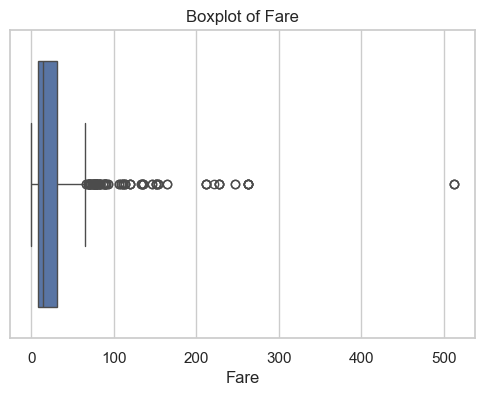

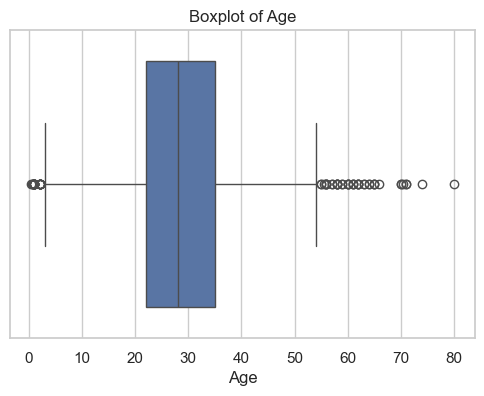

In [1680]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Fare'])
plt.title("Boxplot of Fare")

plt.figure(figsize=(6,4))
sns.boxplot(x=df['Age'])
plt.title("Boxplot of Age")

plt.show()


The boxplots were used to detect outliers in the Age and Fare features. Points located outside the whiskers represent potential outliers according to the IQR method. The Fare feature contains several extreme values, while the Age feature contains a smaller number of outliers. These extreme observations may affect statistical analysis and machine learning models, so they should be handled appropriately before modeling.

### Detect Outliers using IQR
**Method: Interquartile Range (IQR)**

The IQR method defines outliers as values outside:

`Q1 - 1.5×IQR`  and  `Q3 + 1.5×IQR`

In [1681]:
# IQR for Fare
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

lower_bound_fare = Q1_fare - 1.5 * IQR_fare
upper_bound_fare = Q3_fare + 1.5 * IQR_fare

# IQR for Age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

outliers_fare = df[(df['Fare'] < lower_bound_fare) | (df['Fare'] > upper_bound_fare)]
outliers_age = df[(df['Age'] < lower_bound_age) | (df['Age'] > upper_bound_age)]

print("Number of Outliers in Fare:", len(outliers_fare))
print("Number of Outliers in Age:", len(outliers_age))

Number of Outliers in Fare: 116
Number of Outliers in Age: 66


Outliers were detected using the IQR method on the Fare and age columns. A total of 116 outliers were identified in the column Fare and 66 outliers in the age column . These values fall outside the acceptable range and may influence model performance.

### Remove Outliers
We remove values outside the acceptable range.

In [1682]:
# IQR for Age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

# IQR for Fare
Q1_fare = df['Fare'].quantile(0.25)
Q3_fare = df['Fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare

# Remove outliers from both
df_no_outliers = df[
    (df['Age'] >= Q1_age - 1.5*IQR_age) & (df['Age'] <= Q3_age + 1.5*IQR_age) &
    (df['Fare'] >= Q1_fare - 1.5*IQR_fare) & (df['Fare'] <= Q3_fare + 1.5*IQR_fare)
]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)

Original shape: (891, 11)
After removing outliers: (721, 11)


The IQR method was applied to identify and remove outliers from the Age and Fare features. Values falling below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR were considered outliers and removed from the dataset.

The dataset originally contained 891 records. After removing outliers, the dataset size decreased to 721 records. This indicates that 170 observations were identified as outliers and removed.

Removing extreme values helps reduce noise, improve data quality, and minimize the impact of unusual observations on subsequent analysis and machine learning models.

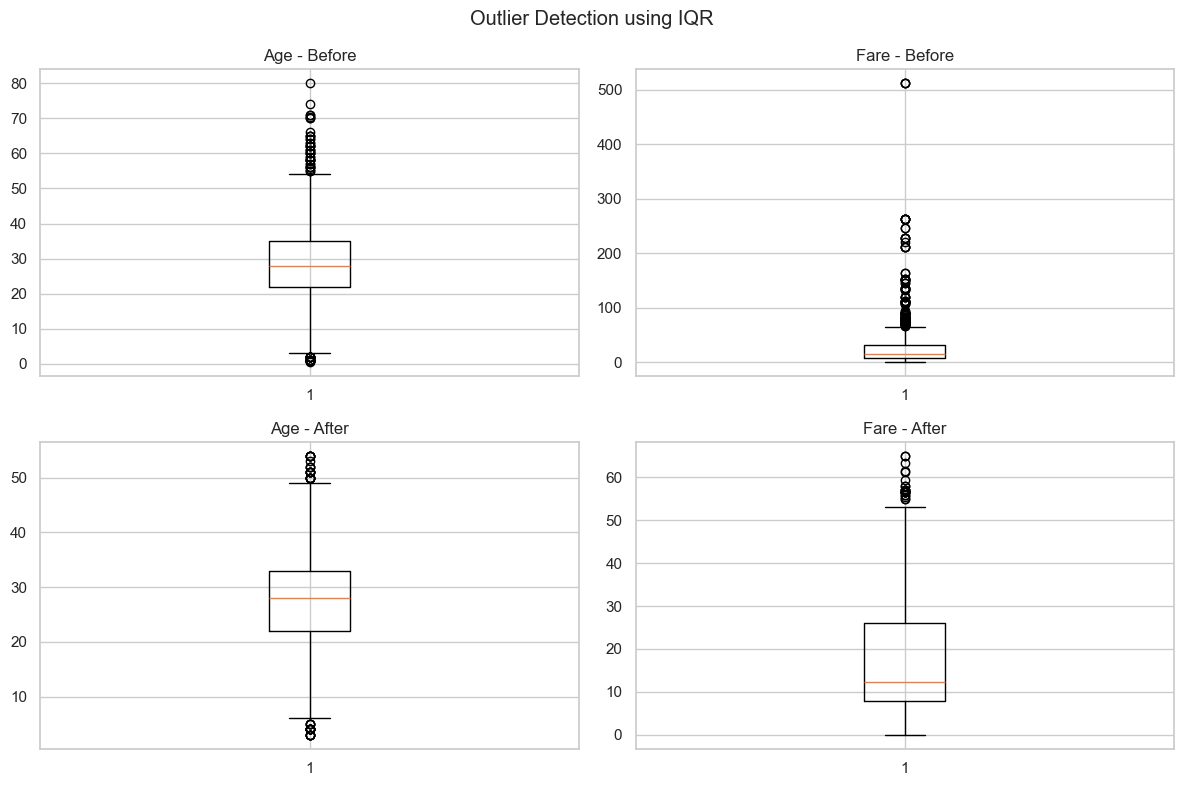

In [1683]:
# Boxplot Before and After for both Age and Fare
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0][0].boxplot(df['Age'])
axes[0][0].set_title('Age - Before')

axes[0][1].boxplot(df['Fare'])
axes[0][1].set_title('Fare - Before')

axes[1][0].boxplot(df_no_outliers['Age'])
axes[1][0].set_title('Age - After')

axes[1][1].boxplot(df_no_outliers['Fare'])
axes[1][1].set_title('Fare - After')

plt.suptitle('Outlier Detection using IQR')
plt.tight_layout()
plt.show()


The boxplots compare the Age and Fare features before and after applying the IQR method for outlier removal.

Before applying IQR, both features contained several extreme values outside the whiskers, especially in the Fare feature. After removing the outliers, the distributions became more compact and the number of extreme observations was significantly reduced.

The dataset size decreased from 891 records to 721 records, indicating that outlier observations were successfully removed. This preprocessing step helps improve data quality and reduces the influence of extreme values on subsequent analysis and machine learning model



#### Important Note on Removing Outliers

Not all outliers are errors.

Some extreme values may represent rare but important real-world events.  
For example, in a sales dataset, a very large transaction might correspond to a bulk corporate order or a seasonal promotion.  

If we remove such values blindly, we may lose valuable information and bias the analysis.

Before removing outliers, we should always ask:
- Is this value a data entry mistake?
- Or is it a valid but rare observation?

### Capping Outliers (Percentile Method)    
Instead of removing outliers, we replace extreme values with percentile limits.

![percentile.png](img/percentile.png)

In [1684]:
lower_cap = df['Fare'].quantile(0.05)
upper_cap = df['Fare'].quantile(0.95)

df_capped = df.copy()
df_capped['Fare'] = df_capped['Fare'].clip(lower_cap, upper_cap)

df_capped[['Fare']].describe()

lower_cap_age = df['Age'].quantile(0.05)
upper_cap_age = df['Age'].quantile(0.95)
df_capped['Age'] = df_capped['Age'].clip(lower_cap_age, upper_cap_age)

df_capped[['Age', 'Fare']].describe()

,Age,Fare
count,891.000000,891.000000
mean,29.157127,27.857570
std,11.728914,29.112872
min,6.000000,7.225000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,54.000000,112.079150


## Task 4: Normalize Numerical Features using Min-Max and Z-score

## 5. Data Transformation – Normalization
Normalization scales numerical features to a similar range.
This ensures that no feature influences the model simply because it has larger numerical values.

### Min-Max Normalization
Min-Max normalization rescales numerical values to a fixed range, usually between 0 and 1.

It works using the formula:
![min_max.png](img/min_max.png)

This method preserves the original distribution shape and relative ordering of values.

Min-Max normalization is especially useful for distance-based models such as:
- K-Nearest Neighbors (KNN)
- K-Means clustering
- Support Vector Machines (SVM)

These models rely on distance calculations, and if features are on very different scales, one feature can dominate the distance computation.

In [1685]:
df[['Age', 'Fare']].head()

,Age,Fare
0,22.0,7.2500
1,38.0,71.2833
2,26.0,7.9250
3,35.0,53.1000
4,35.0,8.0500


In [1686]:
df_scaled = df_no_outliers[['Age', 'Fare']].copy()       

df_scaled['Age_Normalized'] = (
    (df_scaled['Age'] - df_scaled['Age'].min()) /
    (df_scaled['Age'].max() - df_scaled['Age'].min())
)

df_scaled['Fare_Normalized'] = (
    (df_scaled['Fare'] - df_scaled['Fare'].min()) /
    (df_scaled['Fare'].max() - df_scaled['Fare'].min())
)

df_scaled.head()

,Age,Fare,Age_Normalized,Fare_Normalized
0,22.0,7.2500,0.372549,0.111538
2,26.0,7.9250,0.450980,0.121923
3,35.0,53.1000,0.627451,0.816923
4,35.0,8.0500,0.627451,0.123846
5,28.0,8.4583,0.490196,0.130128


After applying Min-Max normalization, all numerical values are scaled to the range between 0 and 1.

The smallest value in each feature becomes 0, and the largest becomes 1.
All other values are proportionally mapped between these two limits.

Importantly, normalization does NOT change the relative relationships between data points.
Min-Max normalization makes features comparable by bringing them to the same scale without changing their relative order.

### Z-Score Normalization
Z-score standardization transforms the data so that:

- The mean of each feature becomes 0
- The standard deviation becomes 1

This is done by subtracting the mean and dividing by the standard deviation:

![zscore.png](img/zscore.png)

This method keeps the shape of the distribution but rescales it around zero.

In [1687]:
df_standardized = df_no_outliers[['Age', 'Fare']].copy()

df_standardized['Age_Zscore'] = (
    (df_standardized['Age'] - df_standardized['Age'].mean())
    / df_standardized['Age'].std()
)

df_standardized['Fare_Zscore'] = (
    (df_standardized['Fare'] - df_standardized['Fare'].mean())
    / df_standardized['Fare'].std()
)

df_standardized.head()

,Age,Fare,Age_Zscore,Fare_Zscore
0,22.0,7.2500,-0.608096,-0.747609
2,26.0,7.9250,-0.208972,-0.697841
3,35.0,53.1000,0.689055,2.632903
4,35.0,8.0500,0.689055,-0.688625
5,28.0,8.4583,-0.009411,-0.658521


After standardization, the numerical features are centered around 0.
Values above the original mean become **positive**, and values below the mean become **negative**.

The standard deviation of each feature becomes approximately 1, meaning the spread of the data is standardized.

This transformation is especially useful for:
- Linear regression
- Support Vector Machines (SVM)
- PCA

Because these models assume features are centered and scaled similarly.

## Task 5:

## Check Correlation Before Applying PCA

we will check whether numerical features are correlated. If features are strongly correlated, they contain overlapping information.

- **Correlation close to 1**  → Strong positive linear relationship  
  (As one feature increases, the other also increases.)

- **Correlation close to -1** → Strong negative linear relationship  
  (As one feature increases, the other decreases.)

- **Correlation close to 0**  → Weak or no linear relationship  
  (The features do not move together in a predictable linear way.)

In such cases, dimensionality reduction using PCA is meaningful 
because we can combine correlated features into fewer components.

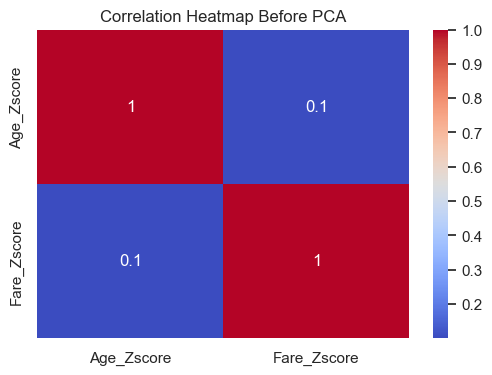

In [1688]:
plt.figure(figsize=(6,4))
sns.heatmap(
    df_standardized[['Age_Zscore', 'Fare_Zscore']].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap Before PCA")
plt.show()

The heatmap shows the correlation between Age_Zscore and Fare_Zscore.

The diagonal values are equal to 1 because each feature is perfectly correlated with itself.

The correlation between Age_Zscore and Fare_Zscore is approximately 0.097.

Since the correlation value is close to 0, there is only a very weak linear relationship between the two features.

This indicates that Age and Fare do not strongly move together and contain mostly different information.
Therefore, PCA is not expected to achieve substantial dimensionality reduction because the two features share very little information. However, PCA can still be used to transform the data into principal components and analyze variance distribution.

## 6. Data Reduction – Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique.

Instead of working directly with the original features, PCA creates new features called **principal components**.

These components:

- Are linear combinations of the original features
- Are uncorrelated with each other
- Capture variance in descending order (from most important to least)

The first principal component (PC1) captures the largest possible variance in the dataset.

The second principal component (PC2) captures the next largest variance, while being orthogonal (perpendicular) to PC1.

This allows us to reduce dimensionality while retaining most of the important information in the data.

### Visual Intuition

Imagine we have two features:

X1 = Amount  
X2 = Boxes Shipped  

If we plot the data points, they may look like this:

              X2
               |
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1

Notice that the points follow a diagonal pattern.
This means the two features are correlated and contain overlapping information.

Instead of keeping both X1 and X2 separately,
PCA finds the direction where the data varies the most.

That direction becomes **Principal Component 1 (PC1)**.

              X2
               |
               |        *
               |      *
               |    *
               |  *
               | *
               |________________________ X1
                    \
                     \
                      \
                       \
                        → PC1 (maximum variance direction)

PC2 is the direction perpendicular to PC1.

If most of the variation is along PC1,
then PC1 alone captures most of the dataset’s information.

In that case, we can reduce:

2 features → 1 feature (PC1)

while keeping most of the variance.

In [1689]:
X = df_standardized[['Age_Zscore', 'Fare_Zscore']].values

# Covariance matrix
cov_matrix = np.cov(X.T)

# Eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Explained variance ratio
explained_variance_ratio = eigenvalues / np.sum(eigenvalues)

# Principal components
principal_components = X.dot(eigenvectors)

print("Explained Variance Ratio:", explained_variance_ratio)

Explained Variance Ratio: [0.44943845 0.55056155]


PCA was applied using the standardized Age and Fare features. The explained variance ratio shows how much variance is captured by each principal component. Since the correlation between Age and Fare was weak, PCA may not greatly reduce the information into one component.

PC1 explains approximately 44.94% of the variance, while PC2 explains approximately 55.06%.

Since the variance is distributed almost equally between the two components, reducing the dataset to a single component would result in a noticeable loss of information.

This is expected because the correlation between Age and Fare is weak.

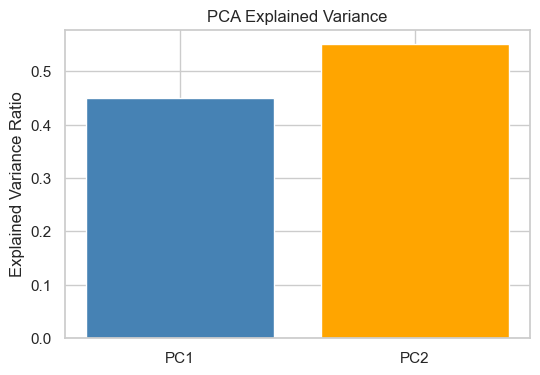

In [1690]:
plt.figure(figsize=(6,4))
plt.bar(['PC1', 'PC2'], [0.44943845, 0.55056155], color=['steelblue','orange'])
plt.ylabel('Explained Variance Ratio')
plt.title('PCA Explained Variance')
plt.show()

The bar chart shows the explained variance ratio of the two principal components obtained from PCA.

PC1 explains approximately 44.94% of the total variance, while PC2 explains approximately 55.06%. The variance is distributed almost equally between the two components, indicating that both components contain important information.

Since neither component captures a dominant portion of the variance, reducing the dataset to a single principal component would result in a noticeable loss of information. This result is consistent with the weak correlation between Age and Fare.

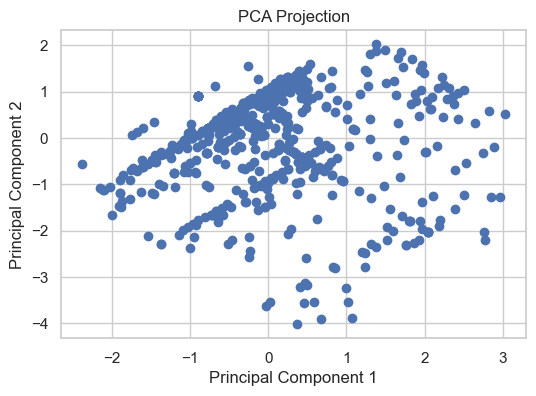

In [1691]:
plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])
plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.show()

Each point in this plot represents one passenger from the Titanic dataset.

The axes no longer represent the original features (Age and Fare).
Instead:

- The horizontal axis represents Principal Component 1 (PC1).
- The vertical axis represents Principal Component 2 (PC2).

PC1 captures one major direction of variation in the data, while PC2 captures another important direction.

The scatter plot shows that the data is distributed across both principal components, which is consistent with the explained variance results (PC1 ≈ 44.94% and PC2 ≈ 55.06%).

This indicates that both components contribute significantly to representing the dataset, and reducing the data to a single component would result in some information loss.

The PCA projection helps visualize the data in a lower-dimensional space while preserving the overall variance structure.

# Assignment

In this assignment, you will:
- **Task 1**
Identify data quality issues in the dataset.

- **Task 2**
Apply one missing value strategy and explain why.

- **Task 3**
Detect and handle outliers using IQR.

- **Task 4**
Normalize numerical features using both Min-Max and Z-score.

- **Task 5**
Apply PCA and interpret explained variance.


End of Assignment 2